# **Taller 3**

**Integrante:**
Anthony Alvarado 27.321.522

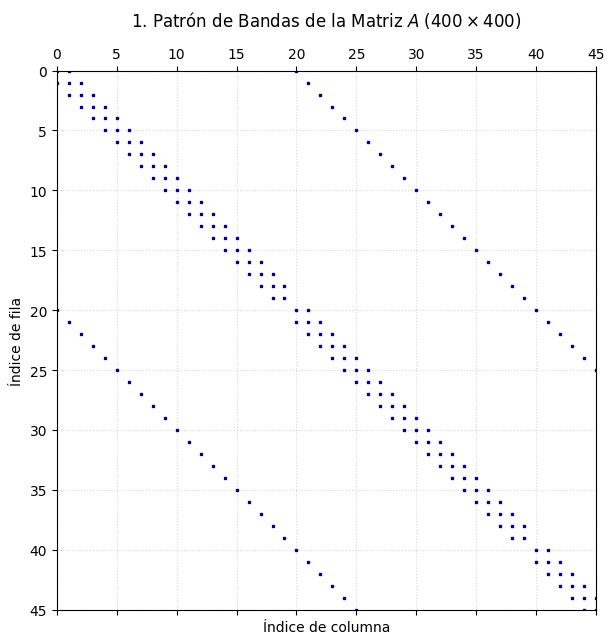

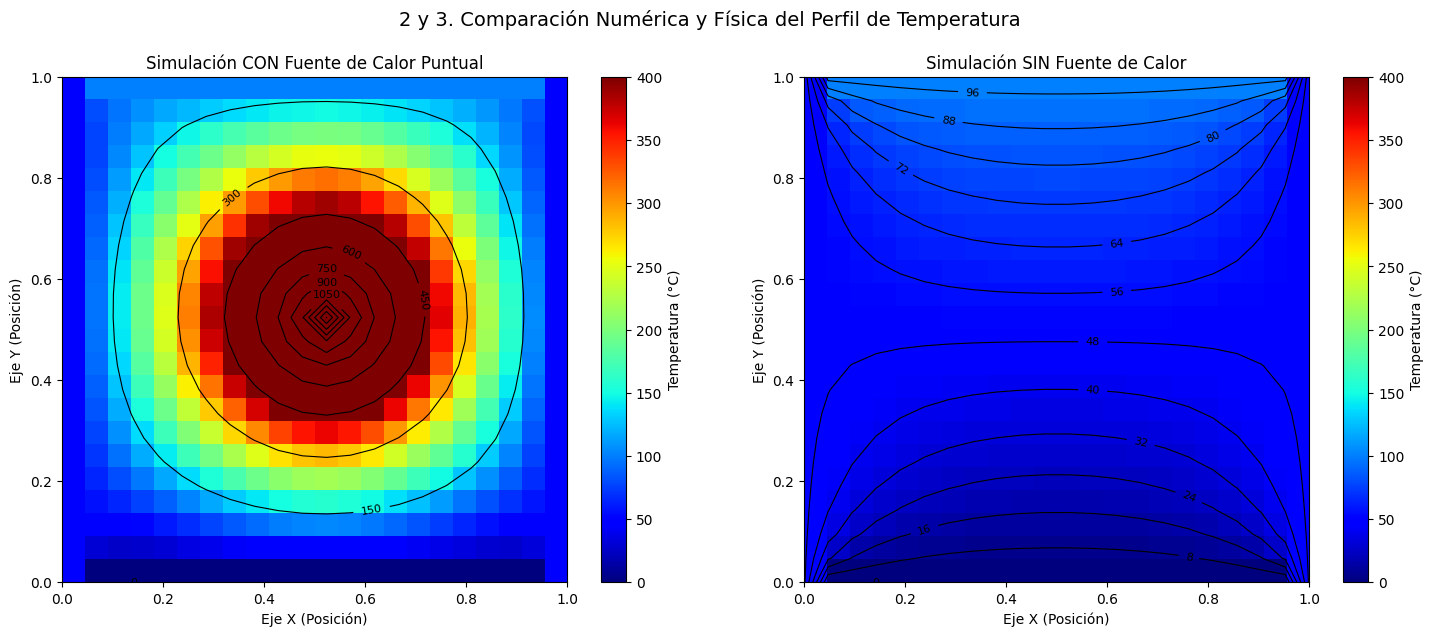

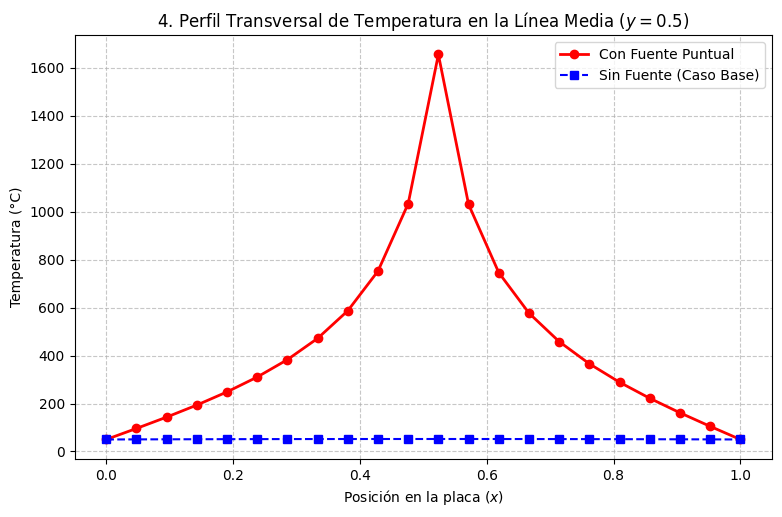

In [1]:
#Librerias:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
#Codigo:

# Primero creo las variables y constantes dadas por el problema.

n = 20                  #Nodos internos por lado.
N_total = n * n         #Total de incognitas(que dice ser 400).
h = 1.0 / (n + 1)       #Distancia entre nodos.

#Temperaturas borde.

T_sup = 100.0
T_inf = 0.0
T_izq = 50.0
T_der = 50.0

# Fuente de calor puntual en el centro (x=0.5, y=0.5)

i_centro = n // 2
j_centro = n // 2
intensidad_fuente = 1100000.0         #<-------MODIFICAR LA TEMPERATURA AQUI.



# CONSTRUCCION DEL CASO CON LA FUENTE DE CALOR:

#Creacion de matriz A y el vector b para este caso.

A_con = sparse.lil_matrix((N_total, N_total))
b_con = np.zeros(N_total)

#Inicializacion:

for i in range(n):
    for j in range(n):
        k = i * n + j  # Mapeo de la malla 2D al índice lineal de la fila

        # Nodo central (nodo actual)
        A_con[k, k] = 4.0

        # Vecino Izquierdo (j - 1)
        if j > 0:
            A_con[k, k - 1] = -1.0
        else:
            b_con[k] += T_izq  # Frontera izquierda -> Va al vector de carga

        # Vecino Derecho (j + 1)
        if j < n - 1:
            A_con[k, k + 1] = -1.0
        else:
            b_con[k] += T_der  # Frontera derecha -> Va al vector de carga

        # Vecino Inferior (i - 1)
        if i > 0:
            A_con[k, k - n] = -1.0
        else:
            b_con[k] += T_inf  # Frontera inferior -> Va al vector de carga

        # Vecino Superior (i + 1)
        if i < n - 1:
            A_con[k, k + n] = -1.0
        else:
            b_con[k] += T_sup  # Frontera superior -> Va al vector de carga

        # Aplicacion de la funete de calor
        if i == i_centro and j == j_centro:
            b_con[k] += (h**2) * intensidad_fuente

# Convertimos la matriz al formato CSR para resolver de forma eficiente
A_con = A_con.tocsr()


#Ahora, ya construido el que tiene la fuente de calor se hace la que
#no tiene fuente de calor ya que en una pide comparar.

#Creacion de matriz A y el vector b para este caso.
A_sin = sparse.lil_matrix((N_total, N_total))
b_sin = np.zeros(N_total)

#Inicializacion:

for i in range(n):
    for j in range(n):
        k = i * n + j  # Mapeo idéntico

        A_sin[k, k] = 4.0

        if j > 0:
            A_sin[k, k - 1] = -1.0
        else:
            b_sin[k] += T_izq

        if j < n - 1:
            A_sin[k, k + 1] = -1.0
        else:
            b_sin[k] += T_der

        if i > 0:
            A_sin[k, k - n] = -1.0
        else:
            b_sin[k] += T_inf

        if i < n - 1:
            A_sin[k, k + n] = -1.0
        else:
            b_sin[k] += T_sup

        # Aquí no se agrega la fuente de calor

A_sin = A_sin.tocsr()


#Resolvemos los sistemas lineales:

u_con_vec = spla.spsolve(A_con, b_con)
u_sin_vec = spla.spsolve(A_sin, b_sin)

#Como esta funcion anterior nos devuelve los vectores los organizamos
#para tenerlo como una matriz.

U_interno_con = u_con_vec.reshape((n, n))
U_interno_sin = u_sin_vec.reshape((n, n))

#Se agregan unos bordes para los valores iniciales de los mismos.

U_completa_con = np.zeros((n + 2, n + 2))
U_completa_sin = np.zeros((n + 2, n + 2))

#Se agregan los resultados al centro de la matriz.

U_completa_con[1:-1, 1:-1] = U_interno_con
U_completa_sin[1:-1, 1:-1] = U_interno_sin

#Se agregan los valores reales de los bordes.

# Fila inferior (y = 0)
U_completa_con[0, :] = T_inf
U_completa_sin[0, :] = T_inf

# Fila superior (y = 1)
U_completa_con[-1, :] = T_sup
U_completa_sin[-1, :] = T_sup

# Columna izquierda (x = 0)
U_completa_con[:, 0] = T_izq
U_completa_sin[:, 0] = T_izq


# Columna derecha (x = 1)
U_completa_con[:, -1] = T_der
U_completa_sin[:, -1] = T_der


#Aqui ya tenemos armada la matriz con y sin fuente de calor.

#GRAFICAS


# Primero definimos los ejes espaciales (x, y) de la placa completa (22x22 puntos)
# para que las escalas de los gráficos muestren valores de 0 a 1.
x_placa = np.linspace(0, 1, n + 2)
y_placa = np.linspace(0, 1, n + 2)
X, Y = np.meshgrid(x_placa, y_placa)

#Matriz de patron de bandas
plt.figure(figsize=(7, 7))

plt.spy(A_con, markersize=1.5, color='darkblue')
plt.xlim(0, 45)
plt.ylim(45, 0)
plt.title("1. Patrón de Bandas de la Matriz $A$ ($400 \\times 400$)", fontsize=12, pad=15)
plt.xlabel("Índice de columna")
plt.ylabel("Índice de fila")
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()

#Isometrico y de calor, ademas de la comparacion visual.
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

#Con Fuente de Calor
im1 = axs[0].imshow(U_completa_con, extent=[0, 1, 0, 1], origin='lower', cmap='jet', vmin=0, vmax=400)
fig.colorbar(im1, ax=axs[0], label='Temperatura (°C)')
# Agregamos las curvas de nivel
cp1 = axs[0].contour(X, Y, U_completa_con, colors='black', levels=15, linewidths=0.8)
axs[0].clabel(cp1, inline=True, fontsize=8, fmt='%1.0f')
axs[0].set_title("Simulación CON Fuente de Calor Puntual")
axs[0].set_xlabel("Eje X (Posición)")
axs[0].set_ylabel("Eje Y (Posición)")

#Sin Fuente de Calor
im2 = axs[1].imshow(U_completa_sin, extent=[0, 1, 0, 1], origin='lower', cmap='jet', vmin=0, vmax=400)
fig.colorbar(im2, ax=axs[1], label='Temperatura (°C)')
# Agregamos las curvas de nivel
cp2 = axs[1].contour(X, Y, U_completa_sin, colors='black', levels=15, linewidths=0.8)
axs[1].clabel(cp2, inline=True, fontsize=8, fmt='%1.0f')
axs[1].set_title("Simulación SIN Fuente de Calor")
axs[1].set_xlabel("Eje X (Posición)")
axs[1].set_ylabel("Eje Y (Posición)")

plt.suptitle("2 y 3. Comparación Numérica y Física del Perfil de Temperatura", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#Perfil transversal
idx_y_centro = i_centro + 1

plt.figure(figsize=(9, 5.5))
plt.plot(x_placa, U_completa_con[idx_y_centro, :], 'r-o', linewidth=2, label='Con Fuente Puntual')
plt.plot(x_placa, U_completa_sin[idx_y_centro, :], 'b--s', linewidth=1.5, label='Sin Fuente (Caso Base)')
plt.title("4. Perfil Transversal de Temperatura en la Línea Media ($y = 0.5$)", fontsize=12)
plt.xlabel("Posición en la placa ($x$)")
plt.ylabel("Temperatura (°C)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()